# Chain Model Evaluation - US Traffic Incident Analysis
ในขั้นตอนนี้เราจะนำ Model ทั้งสองตัวที่ Train ไว้มาทดสอบกับ Test Set โดยใช้กระบวนการแบบ Chain:
1. ใช้ **Model 1** ทำนาย `Distance(mi)` จาก Features พื้นฐาน
2. นำ `Distance(mi)` ที่ทำนายได้ ไปรวมกับ Features พื้นฐาน
3. ใช้ **Model 2** ทำนาย `Duration(min)`
4. วัดผลลัพธ์สุดท้ายเปรียบเทียบกับคำตอบจริง (Ground Truth)

In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load Test Data & Models

In [5]:
# โหลด Features ของ Test Set
X_test = pd.read_csv("../data/processed/03/test_features.csv")

# Bool columns from CSV stay as bool dtype — cast to int so XGBoost treats them as numeric
bool_cols = X_test.select_dtypes(include='bool').columns.tolist()
X_test[bool_cols] = X_test[bool_cols].astype(int)

# โหลดคำตอบจริง (Ground Truth)
y_true = pd.read_csv("../data/processed/01.2/test_secret_answers.csv")

# โหลด Models & Metadata
model_dist = joblib.load("../models/chain_dist_model.pkl")
model_dur  = joblib.load("../models/chain_dur_model.pkl")
metadata   = joblib.load("../models/chain_metadata.pkl")

num_features     = metadata["num_features"]
num_features_dur = metadata["num_features_dur"]
USE_LOG_TARGET   = metadata["use_log_target"]

print(f"X_test shape      : {X_test.shape}")
print(f"y_true shape      : {y_true.shape}")
print(f"num_features      : {len(num_features)}")
print(f"num_features_dur  : {len(num_features_dur)}")
print(f"use_log_target    : {USE_LOG_TARGET}")

X_test shape      : (1367273, 59)
y_true shape      : (1367273, 2)
num_features      : 45
num_features_dur  : 46
use_log_target    : True


## 2. Step 1: Predict Distance
ใช้ Model 1 ทำนายระยะทาง

In [6]:
print("Predicting Distance...")
# Select only the numeric features the model was trained on
X_test_dist = X_test[num_features].astype('float32')
pred_distance_log = model_dist.predict(X_test_dist)

# Invert log1p transform if the model was trained in log space
pred_distance = np.expm1(pred_distance_log) if USE_LOG_TARGET else pred_distance_log
pred_distance = np.clip(pred_distance, 0, None)

# ตรวจสอบผลลัพธ์ของ Model 1
dist_mae  = mean_absolute_error(y_true["Distance(mi)"], pred_distance)
dist_rmse = np.sqrt(mean_squared_error(y_true["Distance(mi)"], pred_distance))
dist_r2   = r2_score(y_true["Distance(mi)"], pred_distance)
print(f"Distance  MAE : {dist_mae:.4f}")
print(f"Distance  RMSE: {dist_rmse:.4f}")
print(f"Distance  R²  : {dist_r2:.4f}")

Predicting Distance...
Distance  MAE : 0.4662
Distance  RMSE: 1.3872
Distance  R²  : 0.0578


## 3. Step 2: Predict Duration using Predicted Distance
นำผลลัพธ์จาก Step 1 มาเป็น Feature ให้ Model 2

In [7]:
# Add predicted Distance as a feature for Model 2
X_test_dur = X_test[num_features].astype('float32').copy()
X_test_dur["Distance(mi)"] = pred_distance
X_test_dur = X_test_dur[num_features_dur].astype('float32')

print("Predicting Duration...")
pred_duration_log = model_dur.predict(X_test_dur)
pred_duration = np.expm1(pred_duration_log) if USE_LOG_TARGET else pred_duration_log
pred_duration = np.clip(pred_duration, 0, None)

# ตรวจสอบผลลัพธ์ของ Model 2 (Final Prediction)
dur_mae  = mean_absolute_error(y_true["Duration(min)"], pred_duration)
dur_rmse = np.sqrt(mean_squared_error(y_true["Duration(min)"], pred_duration))
dur_r2   = r2_score(y_true["Duration(min)"], pred_duration)

print(f"\n--- Final Evaluation (Duration) ---")
print(f"MAE:  {dur_mae:.4f} minutes")
print(f"RMSE: {dur_rmse:.4f} minutes")
print(f"R2:   {dur_r2:.4f}")

Predicting Duration...

--- Final Evaluation (Duration) ---
MAE:  112.6799 minutes
RMSE: 267.5476 minutes
R2:   -0.2141


## 4. Visualize Results

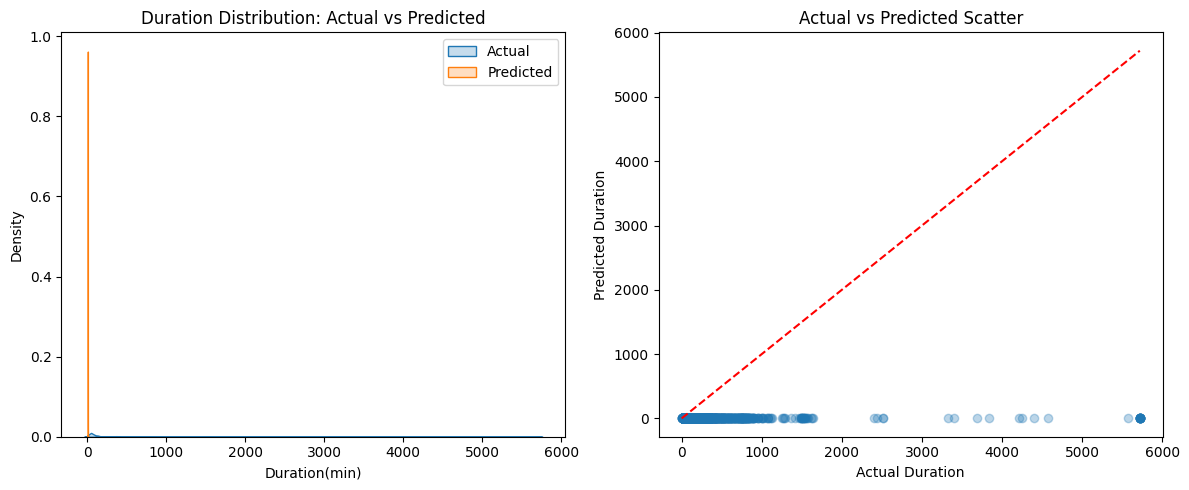

In [8]:
plt.figure(figsize=(12, 5))

# Plot Distribution ของผลการทำนาย vs ความจริง
plt.subplot(1, 2, 1)
sns.kdeplot(y_true["Duration(min)"], label='Actual', fill=True)
sns.kdeplot(pred_duration, label='Predicted', fill=True)
plt.title("Duration Distribution: Actual vs Predicted")
plt.legend()

# Scatter Plot แสดงความสัมพันธ์ (สุ่มมา 10,000 จุดเพื่อให้กราฟไม่แน่นเกินไป)
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(y_true), 10000, replace=False)
plt.scatter(y_true["Duration(min)"].iloc[sample_idx], pred_duration[sample_idx], alpha=0.3)
plt.plot([y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 
         [y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 'r--')
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted Scatter")

plt.tight_layout()
plt.show()

## 5. Error Analysis
ดูว่าอุบัติเหตุประเภทไหนที่ Model ทำนายพลาดมากที่สุด

In [9]:
error_df = X_test.copy()
error_df['Actual_Duration'] = y_true['Duration(min)']
error_df['Pred_Duration'] = pred_duration
error_df['Absolute_Error'] = np.abs(error_df['Actual_Duration'] - error_df['Pred_Duration'])

print("Top 5 states with highest average error:")
if 'State' in error_df.columns:
    print(error_df.groupby('State')['Absolute_Error'].mean().sort_values(ascending=False).head())
else:
    # ถ้า State ถูก Encode ไปแล้ว ลองดูตาม Weather_Group
    print(error_df.groupby('Weather_Group')['Absolute_Error'].mean().sort_values(ascending=False).head())

Top 5 states with highest average error:
State
LA    264.267009
OR    251.861289
WV    251.675851
SD    247.456421
WY    246.777662
Name: Absolute_Error, dtype: float64
